In [2]:
import pandas as pd

train_path = "../data/raw/aps_failure_training_set.csv"

df = pd.read_csv(
    train_path,
    skiprows=20,
    na_values="na"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (60000, 171)


In [3]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000', 'cl_000'

In [5]:
print("Target class distribution:")
print(df["class"].value_counts())

Target class distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


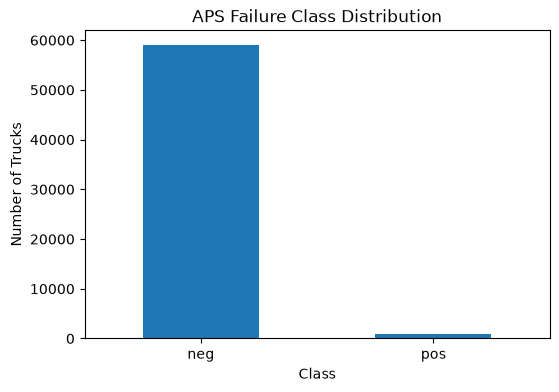

In [6]:
import matplotlib.pyplot as plt

class_counts = df["class"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("APS Failure Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Trucks")
plt.xticks(rotation=0)
plt.show()

In [7]:
# ==========================================
# DATA UNDERSTANDING AND CLEANING
# ==========================================

# 1. Basic information
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

# 2. Check missing values
missing_values = df.isnull().sum()

print("\nTotal missing values:")
print(missing_values.sum())

print("\nColumns with missing values:")
print(missing_values[missing_values > 0].sort_values(ascending=False).head(20))

# 3. Check duplicate rows
duplicates = df.duplicated().sum()

print("\nDuplicate rows:", duplicates)

# 4. Target distribution
print("\nTarget distribution:")
print(df["class"].value_counts())

print("\nTarget percentage:")
print(df["class"].value_counts(normalize=True) * 100)

# 5. Basic statistical summary
print("\nStatistical summary:")
display(df.describe(include="all").T.head(20))

# 6. Missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nTop columns by missing-value percentage:")
display(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
    .head(20)
)

Dataset shape: (60000, 171)

Data types:
float64    169
str          1
int64        1
Name: count, dtype: int64

Total missing values:
850015

Columns with missing values:
br_000    49264
bq_000    48722
bp_000    47740
bo_000    46333
cr_000    46329
ab_000    46329
bn_000    44009
bm_000    39549
bl_000    27277
bk_000    23034
ad_000    14861
cf_000    14861
ch_000    14861
cg_000    14861
co_000    14861
cy_000    13808
cz_000    13808
cx_000    13808
cv_000    13808
ct_000    13808
dtype: int64

Duplicate rows: 0

Target distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64

Target percentage:
class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
class,60000,2,neg,59000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aa_000,60000.0,NaN,NaN,NaN,59336.499567,145430.056532,0.0,834.0,30776.0,48668.0,2746564.0
ab_000,13671.0,NaN,NaN,NaN,0.713189,3.478962,0.0,0.0,0.0,0.0,204.0
ac_000,56665.0,NaN,NaN,NaN,356014263.031466,794874918.4803,0.0,16.0,152.0,964.0,2130706796.0
ad_000,45139.0,NaN,NaN,NaN,190620.639314,40404411.418324,0.0,24.0,126.0,430.0,8584297742.0
ae_000,57500.0,NaN,NaN,NaN,6.81913,161.543373,0.0,0.0,0.0,0.0,21050.0
af_000,57500.0,NaN,NaN,NaN,11.006817,209.792592,0.0,0.0,0.0,0.0,20070.0
ag_000,59329.0,NaN,NaN,NaN,221.636367,20478.463855,0.0,0.0,0.0,0.0,3376892.0
ag_001,59329.0,NaN,NaN,NaN,975.722261,34200.52953,0.0,0.0,0.0,0.0,4109372.0
ag_002,59329.0,NaN,NaN,NaN,8606.014529,150322.028539,0.0,0.0,0.0,0.0,10552856.0



Top columns by missing-value percentage:


br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
cr_000    77.215000
ab_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
ad_000    24.768333
cf_000    24.768333
ch_000    24.768333
cg_000    24.768333
co_000    24.768333
cy_000    23.013333
cz_000    23.013333
cx_000    23.013333
cv_000    23.013333
ct_000    23.013333
dtype: float64

In [8]:
# ==========================================
# DATA CLEANING AND PREPARATION
# ==========================================

# Convert target variable to numerical values
df["class"] = df["class"].map({"neg": 0, "pos": 1})

# Separate target from features
X = df.drop(columns=["class"])
y = df["class"]

# Remove columns with more than 70% missing values
missing_ratio = X.isnull().mean()
columns_to_drop = missing_ratio[missing_ratio > 0.70].index

print("Columns before removing sparse features:", X.shape[1])
print("Columns removed:", len(columns_to_drop))

X = X.drop(columns=columns_to_drop)

print("Columns remaining:", X.shape[1])

# Fill remaining missing values with median
X = X.fillna(X.median())

# Verify missing values are handled
print("Remaining missing values:", X.isnull().sum().sum())

# Display final shapes
print("Final feature shape:", X.shape)
print("Target shape:", y.shape)

Columns before removing sparse features: 170
Columns removed: 7
Columns remaining: 163
Remaining missing values: 0
Final feature shape: (60000, 163)
Target shape: (60000,)


In [9]:
# ==========================================
# TRAIN-VALIDATION SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

Training set shape: (48000, 163)
Validation set shape: (12000, 163)

Training target distribution:
class
0    47200
1      800
Name: count, dtype: int64

Validation target distribution:
class
0    11800
1      200
Name: count, dtype: int64


In [10]:
# ==========================================
# BASELINE MODEL
# ==========================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create baseline model
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Train baseline
baseline_model.fit(X_train, y_train)

# Predict validation data
y_pred_baseline = baseline_model.predict(X_val)

# Accuracy
baseline_accuracy = accuracy_score(y_val, y_pred_baseline)

print("Baseline Accuracy:", baseline_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_baseline))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_baseline))

Baseline Accuracy: 0.9833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     11800
           1       0.00      0.00      0.00       200

    accuracy                           0.98     12000
   macro avg       0.49      0.50      0.50     12000
weighted avg       0.97      0.98      0.98     12000


Confusion Matrix:
[[11800     0]
 [  200     0]]


c:\Users\Sai Mahanth\OneDrive\Desktop\Scania-Truck-APS-Failure-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sai Mahanth\OneDrive\Desktop\Scania-Truck-APS-Failure-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sai Mahanth\OneDrive\Desktop\Scania-Truck-APS-Failure-Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

IndentationError: unindent does not match any outer indentation level (<string>, line 23)

In [3]:
# ==========================================
# PREPROCESSING + TRAIN/VALIDATION SPLIT
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
train_path = "../data/raw/aps_failure_training_set.csv"

df = pd.read_csv(
    train_path,
    skiprows=20,
    na_values="na"
)

print("Dataset loaded:", df.shape)

# Convert target to numerical values
df["class"] = df["class"].map({
    "neg": 0,
    "pos": 1
})

# Separate features and target
X = df.drop(columns=["class"])
y = df["class"]

# Remove columns with more than 70% missing values
missing_ratio = X.isnull().mean()

columns_to_drop = missing_ratio[
    missing_ratio > 0.70
].index

X = X.drop(columns=columns_to_drop)

print("Features after removing sparse columns:", X.shape[1])

# Fill remaining missing values with median
X = X.fillna(X.median())

print("Remaining missing values:", X.isnull().sum().sum())

# Stratified train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Validation set:", X_val.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nValidation classes:")
print(y_val.value_counts())

Dataset loaded: (60000, 171)
Features after removing sparse columns: 163
Remaining missing values: 0

Training set: (48000, 163)
Validation set: (12000, 163)

Training classes:
class
0    47200
1      800
Name: count, dtype: int64

Validation classes:
class
0    11800
1      200
Name: count, dtype: int64


In [4]:
# ==========================================
# RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Training completed!")

y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_roc_auc = roc_auc_score(y_val, y_prob_rf)

print("\nRandom Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_roc_auc)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))

Training Random Forest...
Training completed!

Random Forest Accuracy: 0.99175
Random Forest ROC-AUC: 0.9902349576271187

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11800
           1       0.74      0.78      0.76       200

    accuracy                           0.99     12000
   macro avg       0.87      0.89      0.88     12000
weighted avg       0.99      0.99      0.99     12000


Confusion Matrix:
[[11746    54]
 [   45   155]]


<Figure size 700x600 with 0 Axes>

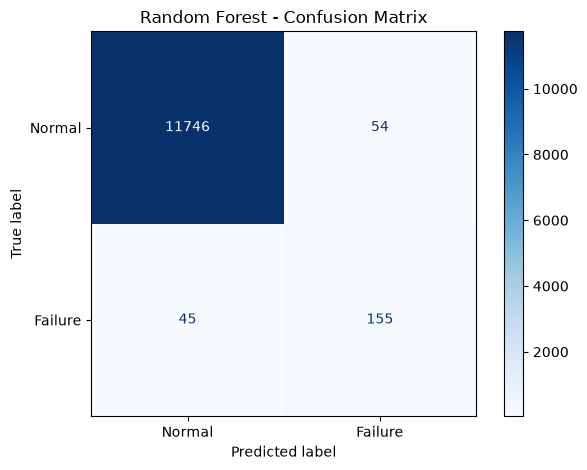

<Figure size 700x600 with 0 Axes>

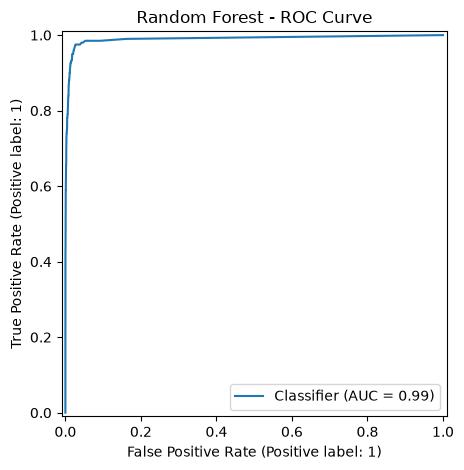

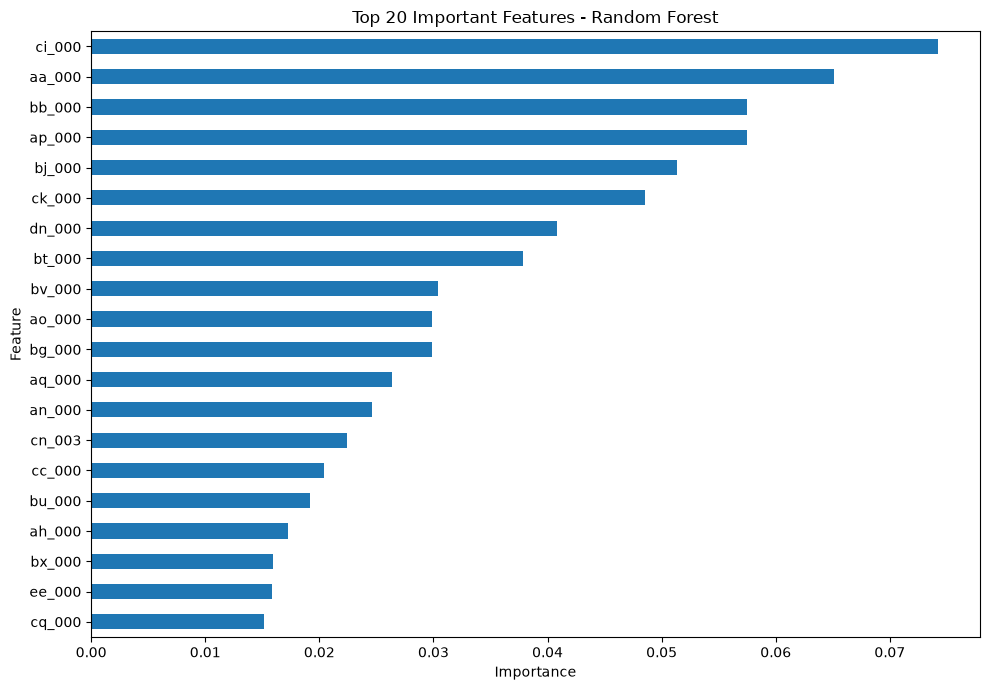


Top 20 Important Features:
ci_000    0.074194
aa_000    0.065095
bb_000    0.057505
ap_000    0.057490
bj_000    0.051348
ck_000    0.048549
dn_000    0.040787
bt_000    0.037855
bv_000    0.030369
ao_000    0.029909
bg_000    0.029891
aq_000    0.026337
an_000    0.024647
cn_003    0.022392
cc_000    0.020388
bu_000    0.019189
ah_000    0.017268
bx_000    0.015937
ee_000    0.015842
cq_000    0.015107
dtype: float64


In [5]:
# ==========================================
# MODEL EVALUATION VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# ------------------------------------------
# 1. Confusion Matrix
# ------------------------------------------

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_rf,
    display_labels=["Normal", "Failure"],
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 2. ROC Curve
# ------------------------------------------

plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_val,
    y_prob_rf
)

plt.title("Random Forest - ROC Curve")
plt.tight_layout()
plt.show()


# ------------------------------------------
# 3. Feature Importance
# ------------------------------------------

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

print("\nTop 20 Important Features:")
print(top_features)


===== MODEL COMPARISON =====
   Metric  Baseline  Random Forest
 Accuracy  0.983333       0.991750
Precision  0.000000       0.741627
   Recall  0.000000       0.775000
 F1-Score  0.000000       0.757946


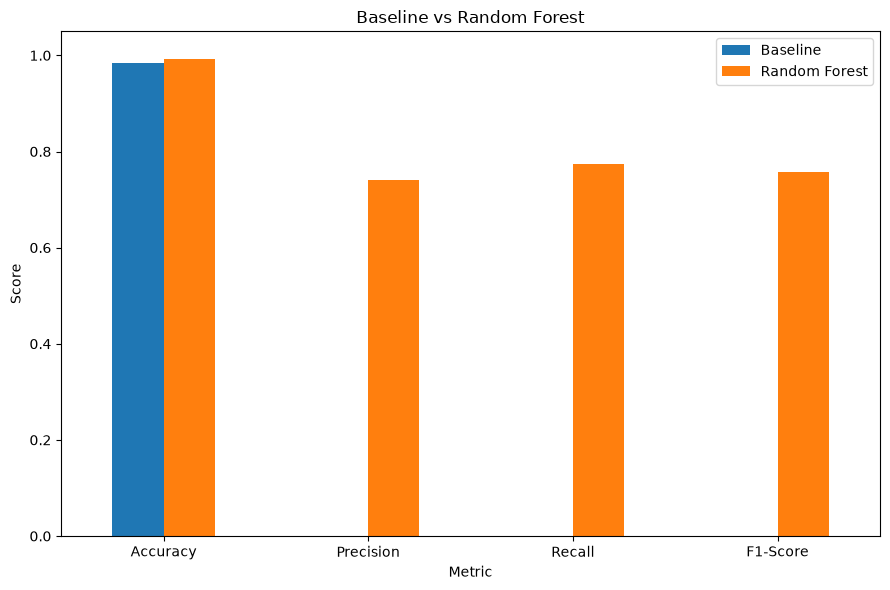

In [6]:
# ==========================================
# BASELINE vs RANDOM FOREST COMPARISON
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Baseline predictions
baseline_pred = [0] * len(y_val)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(y_val, baseline_pred)
baseline_precision = precision_score(y_val, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_val, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_val, baseline_pred, zero_division=0)

# Random Forest metrics
rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_val, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_val, y_pred_rf, zero_division=0)

# Create comparison table
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

print("\n===== MODEL COMPARISON =====")
print(comparison.to_string(index=False))

# ------------------------------------------
# Plot comparison
# ------------------------------------------

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Baseline vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# SAVE RANDOM FOREST MODEL
# ==========================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save model
model_path = "../models/random_forest_aps_model.pkl"

joblib.dump(rf_model, model_path)

print("Model saved successfully!")
print("Location:", model_path)

# Verify saved model
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model file size: {file_size:.2f} MB")

Model saved successfully!
Location: ../models/random_forest_aps_model.pkl
Model file size: 6.16 MB


In [8]:
# ==========================================
# LOAD SAVED MODEL AND TEST PREDICTION
# ==========================================

import joblib
import pandas as pd

# Load saved model
model_path = "../models/random_forest_aps_model.pkl"

loaded_model = joblib.load(model_path)

print("Saved model loaded successfully!")

# Take one real validation sample
sample = X_val.iloc[[0]]

# Actual class
actual = y_val.iloc[0]

# Prediction
prediction = loaded_model.predict(sample)[0]

# Probability
probability = loaded_model.predict_proba(sample)[0][1]

print("\n===== PREDICTION RESULT =====")

if prediction == 1:
    print("Prediction: APS FAILURE")
else:
    print("Prediction: NORMAL")

print(f"Failure probability: {probability:.2%}")

if actual == 1:
    print("Actual result: APS FAILURE")
else:
    print("Actual result: NORMAL")

Saved model loaded successfully!

===== PREDICTION RESULT =====
Prediction: NORMAL
Failure probability: 0.00%
Actual result: NORMAL
